# 1. Configuración de PySpark en Colab


In [1]:
# Instalar Java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Descargar Spark 3.5.1
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

# Extraer los archivos de Spark
!tar xf spark-3.5.1-bin-hadoop3.tgz

# Instalar findspark para facilitar el uso de Spark en Python
!pip install -q findspark

# Configurar las variables de entorno para Java y Spark
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

# Inicializar Spark usando findspark
import findspark
findspark.init()

# Crear la sesión de Spark
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

# Verificar la versión de Spark
print(f"Versión de Spark: {spark.version}")




Versión de Spark: 3.5.1


# 2. Código inicial para generar un grafo en PySpark utilizando Google Colab

In [2]:
# Importar las librerías necesarias
import random
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# Inicializar la sesión de Spark
spark = SparkSession.builder.appName("SocialNetworkGraph").getOrCreate()

# Crear un conjunto de usuarios ficticios con atributos aleatorios (nombre y edad)
usernames = ["Alice", "Bob", "Charlie", "David", "Eve", "Frank", "Grace", "Hank", "Ivy", "Judy"]
users_data = [(name, random.randint(18, 65)) for name in usernames]  # Nombres y edades aleatorias

# Definir el esquema para el DataFrame de usuarios (vértices)
vertices_schema = StructType([
    StructField("id", StringType(), True),
    StructField("age", IntegerType(), True)
])

# Crear un DataFrame de vértices (usuarios)
vertices_df = spark.createDataFrame(users_data, schema=vertices_schema)

# Mostrar los vértices (usuarios y sus edades)
vertices_df.show()

# Crear relaciones aleatorias de seguimiento entre los usuarios
edges_data = []
for follower in usernames:
    # Cada usuario sigue de 1 a 3 personas aleatorias (sin incluirse a sí mismo)
    follows = random.sample([u for u in usernames if u != follower], random.randint(1, 3))
    for followed in follows:
        edges_data.append((follower, followed))

# Definir el esquema para el DataFrame de aristas (relaciones de seguimiento)
edges_schema = StructType([
    StructField("src", StringType(), True),  # El usuario que sigue
    StructField("dst", StringType(), True)   # El usuario seguido
])

# Crear un DataFrame de aristas (relaciones)
edges_df = spark.createDataFrame(edges_data, schema=edges_schema)

# Mostrar las aristas (quién sigue a quién)
edges_df.show()


+-------+---+
|     id|age|
+-------+---+
|  Alice| 62|
|    Bob| 53|
|Charlie| 19|
|  David| 22|
|    Eve| 39|
|  Frank| 57|
|  Grace| 28|
|   Hank| 18|
|    Ivy| 61|
|   Judy| 31|
+-------+---+

+-------+-------+
|    src|    dst|
+-------+-------+
|  Alice|Charlie|
|  Alice|    Bob|
|  Alice|   Hank|
|    Bob|  Frank|
|Charlie|    Ivy|
|Charlie|   Judy|
|Charlie|  Alice|
|  David|    Ivy|
|  David|    Eve|
|  David|Charlie|
|    Eve|  Alice|
|    Eve|    Ivy|
|    Eve|  Frank|
|  Frank|Charlie|
|  Frank|  Alice|
|  Frank|    Eve|
|  Grace|    Eve|
|  Grace|Charlie|
|  Grace|  Frank|
|   Hank|  Alice|
+-------+-------+
only showing top 20 rows



# 3. Ahora vamos a representarlo en grafos usando la librería Networkx

In [3]:
!pip install matplotlib networkx


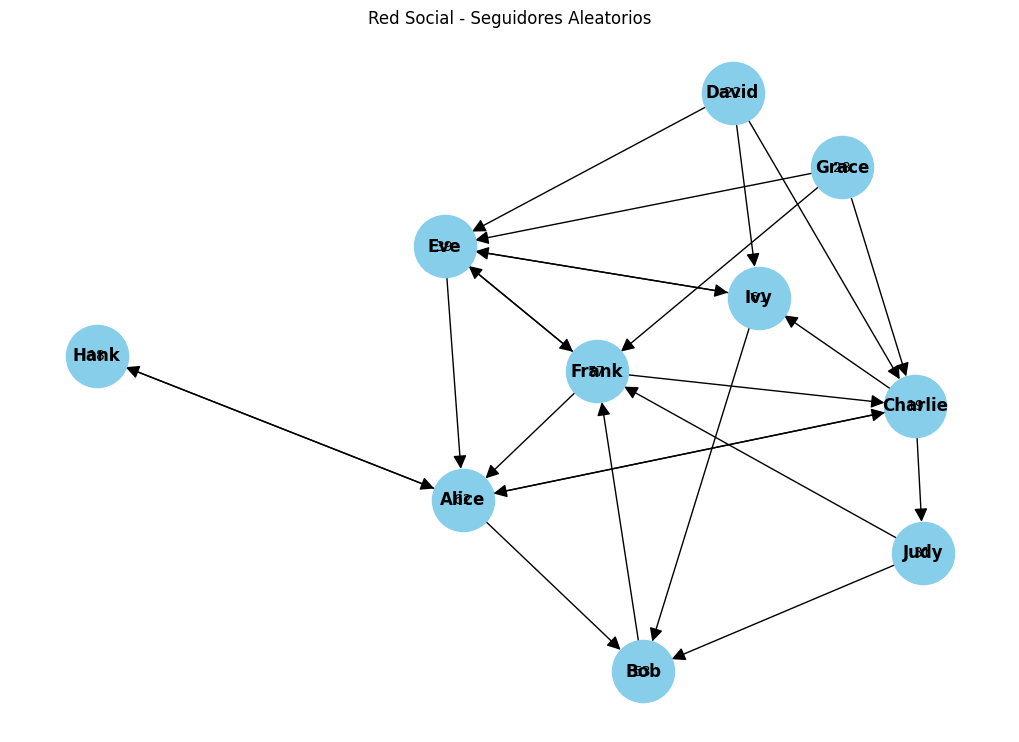

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Convertir los DataFrames de PySpark a listas para usarlas en NetworkX
vertices_list = vertices_df.collect()
edges_list = edges_df.collect()

# Crear un grafo dirigido en NetworkX
G = nx.DiGraph()

# Añadir nodos con sus atributos
for row in vertices_list:
    G.add_node(row['id'], age=row['age'])

# Añadir aristas (relaciones de seguimiento)
for row in edges_list:
    G.add_edge(row['src'], row['dst'])

# Dibujar el grafo
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G)  # Elegir una disposición adecuada de los nodos
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="skyblue", font_size=12, font_weight="bold", arrowsize=20)
node_labels = nx.get_node_attributes(G, 'age')
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10)

plt.title("Red Social - Seguidores Aleatorios")
plt.show()



ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

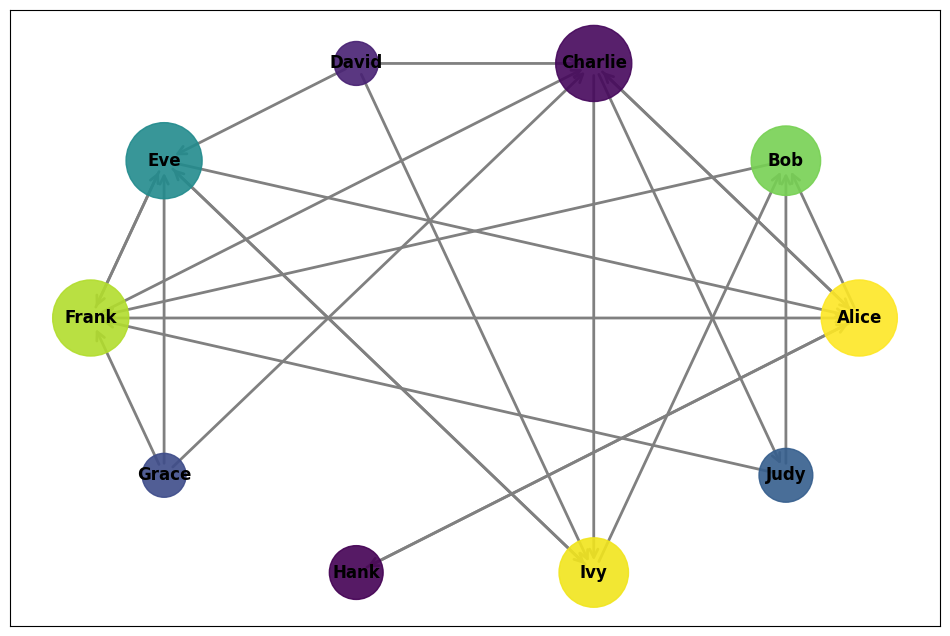

In [6]:
# Crear un nuevo gráfico dirigido en NetworkX
G = nx.DiGraph()

# Añadir los nodos y sus atributos
for row in vertices_list:
    G.add_node(row['id'], age=row['age'])

# Añadir las aristas (relaciones de seguimiento)
for row in edges_list:
    G.add_edge(row['src'], row['dst'])

# Calculamos el número de seguidores para ajustar el tamaño de los nodos
followers_count = {node: G.in_degree(node) for node in G.nodes()}

# Creamos una lista de colores basados en la edad (cuanto más joven, más claro el color)
node_colors = [G.nodes[node]['age'] for node in G.nodes()]

# Dibujamos el grafo
plt.figure(figsize=(12, 8))

# Ajustamos la disposición de los nodos (circular en este caso)
pos = nx.circular_layout(G)

# Dibujar nodos con tamaño basado en el número de seguidores y color por edad
nx.draw_networkx_nodes(G, pos, node_size=[v * 500 + 1000 for v in followers_count.values()],
                       node_color=node_colors, cmap=plt.cm.viridis, alpha=0.9)

# Dibujar las conexiones entre nodos (aristas) con flechas
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray', width=2)

# Añadir etiquetas con los nombres de los nodos
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Añadir color bar para indicar la relación entre edad y color
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])

# Título del gráfico
plt.title("Red Social: Seguidores vs Edad", size=15)

plt.show()
